In [2]:
# Mount Google Drive for Data Storage
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install albumentations opencv-python scikit-image
import os
from sklearn.model_selection import train_test_split


In [3]:
import torch
torch.cuda.empty_cache()


In [4]:
import cv2
import numpy as np
from glob import glob
import albumentations as A

# Adjust the glob pattern to ensure it picks up the correct files
sar_images = glob("/content/drive/MyDrive/SIH/sar/*.tif")
optical_images = glob("/content/drive/MyDrive/SIH/optical/*.tif")

def load_image(file):
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)  # Load as grayscale for SAR
    if img is None:
        print(f"Error loading image: {file}")
        return None  # Return None if the image failed to load
    return cv2.resize(img, (256, 256))  # Resize for consistency

# Filter out None entries (in case some images failed to load)
sar_data = [load_image(img) for img in sar_images[:30] if load_image(img) is not None]
optical_data = [load_image(img) for img in optical_images[:30] if load_image(img) is not None]

# Normalize the data
sar_data = np.array(sar_data) / 255.0
optical_data = np.array(optical_data) / 255.0

#simple data augmentation
aug = A.Compose([
A.HorizontalFlip(p=0.5),
A.Rotate(limit=30, p=0.5)
])

def augment(image):
  return aug(image=image)['image']

# Check the shape of the first image in sar_data and optical_data
print(f"SAR data shape: {sar_data[0].shape}")
print(f"Optical data shape: {optical_data[0].shape}")

# Check min and max pixel values in the first SAR and Optical images
print(f"SAR image min: {sar_data[0].min()}, max: {sar_data[0].max()}")
print(f"Optical image min: {optical_data[0].min()}, max: {optical_data[0].max()}")
#If the pixel values are between 0 and 1 (or normalized as per your mean/std), the preprocessing is correct.


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.16 (you have 1.4.15). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


SAR data shape: (256, 256)
Optical data shape: (256, 256)
SAR image min: 0.00392156862745098, max: 0.996078431372549
Optical image min: 0.06274509803921569, max: 0.9607843137254902


In [4]:
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler, autocast
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
torch.cuda.empty_cache()
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Lightweight Generator with Depthwise Separable Convolutions
class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, num_residual_blocks=3):
        super(Generator, self).__init__()

        # Initial Convolution Block
        model = [nn.Conv2d(input_nc, 32, kernel_size=7, padding=3, bias=False),
                 nn.InstanceNorm2d(32),
                 nn.ReLU(inplace=True)]

        # Downsampling with Depthwise Separable Convolutions
        model += [DepthwiseSeparableConv(32, 64),
                  nn.InstanceNorm2d(64),
                  nn.ReLU(inplace=True)]

        model += [DepthwiseSeparableConv(64, 128),
                  nn.InstanceNorm2d(128),
                  nn.ReLU(inplace=True)]

        # Residual Blocks
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(128)]

        # Upsampling
        model += [nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
                  nn.InstanceNorm2d(64),
                  nn.ReLU(inplace=True)]

        model += [nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
                  nn.InstanceNorm2d(32),
                  nn.ReLU(inplace=True)]

        # Output Layer
        model += [nn.Conv2d(32, output_nc, kernel_size=7, padding=3),
                  nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


# Depthwise Separable Convolution for efficiency
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


# Residual Block remains the same
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.block(x)


# Lightweight Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_nc):
        super(Discriminator, self).__init__()

        # A basic 3-layer PatchGAN discriminator with fewer filters
        model = [
            nn.Conv2d(input_nc, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        ]

        # Final Layer
        model += [nn.Conv2d(256, 1, kernel_size=4, padding=1)]  # Output is still (N, 1, H, W)
        self.model = nn.Sequential(*model)

    def forward(self, x):
        # Pass through the model
        x = self.model(x)
        # Use mean pooling to get a single output per image
        return torch.mean(x, dim=[2, 3])  # Average over H and W

torch.cuda.empty_cache()
# Initialize Models and Optimizers

# Set input_nc and output_nc for your Generator and Discriminator
input_nc = 1  # SAR images are grayscale (single channel)
output_nc = 3  # RGB output (3 channels)

# Instantiate models and move them to device
generator = Generator(input_nc, output_nc).to(device)  # Move to GPU
discriminator = Discriminator(output_nc).to(device)  # Move to GPU


# Define learning rate and beta1 for Adam optimizer
lr = 0.0001
beta1 = 0.5

# Initialize optimizers for generator and discriminator
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Define paths for checkpoints
checkpoint_dir = '/content/drive/MyDrive/checkpoint'

# Function to get the latest epoch number from the filenames
def get_latest_checkpoint(path, model_type='generator'):
    # List all files in the checkpoint directory
    files = os.listdir(path)

    # Filter the files for the specified model (generator or discriminator)
    checkpoint_files = [f for f in files if model_type in f and f.endswith('.pth')]

    # Extract epoch numbers from the filenames
    epoch_numbers = [int(f.split('_epoch_')[-1].split('.pth')[0]) for f in checkpoint_files]

    if epoch_numbers:
        # Get the highest epoch number
        latest_epoch = max(epoch_numbers)

        # Return the corresponding file for the latest epoch
        latest_checkpoint = f'{model_type}_epoch_{latest_epoch}.pth'
        return os.path.join(path, latest_checkpoint), latest_epoch
    else:
        return None, None

# Load the best generator and discriminator checkpoints
def load_best_checkpoint(generator, discriminator, optimizer_G=None, optimizer_D=None):
    # Load the latest generator checkpoint
    gen_checkpoint_path, gen_epoch = get_latest_checkpoint(checkpoint_dir, model_type='generator')
    if gen_checkpoint_path:
        print(f"Loading Generator from: {gen_checkpoint_path}")
        gen_checkpoint = torch.load(gen_checkpoint_path)
        generator.load_state_dict(gen_checkpoint['model_state_dict'])

        # If optimizers are provided, load their states
        if optimizer_G:
            optimizer_G.load_state_dict(gen_checkpoint['optimizer_state_dict'])

        print(f"Generator loaded from epoch {gen_epoch}")

    # Load the latest discriminator checkpoint
    disc_checkpoint_path, disc_epoch = get_latest_checkpoint(checkpoint_dir, model_type='discriminator')
    if disc_checkpoint_path:
        print(f"Loading Discriminator from: {disc_checkpoint_path}")
        disc_checkpoint = torch.load(disc_checkpoint_path)
        discriminator.load_state_dict(disc_checkpoint['model_state_dict'])

        # If optimizers are provided, load their states
        if optimizer_D:
            optimizer_D.load_state_dict(disc_checkpoint['optimizer_state_dict'])

        print(f"Discriminator loaded from epoch {disc_epoch}")

    # Return the latest epoch for both
    return max(gen_epoch, disc_epoch) if gen_epoch and disc_epoch else 0


# Example: Assume you have a generator, discriminator, and optimizers initialized
# generator = Generator(input_nc=1, output_nc=3).to(device)
# discriminator = Discriminator(input_nc=3).to(device)
# optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Load the best checkpoint
last_epoch = load_best_checkpoint(generator, discriminator, optimizer_G, optimizer_D)

print(f"Resuming training from epoch {last_epoch + 1}")

# Assume loss functions are already defined, such as adversarial_loss and pixelwise_loss
adversarial_loss = torch.nn.BCEWithLogitsLoss()  # For binary classification (real vs fake)
pixelwise_loss = torch.nn.L1Loss()  # Or use MSELoss for pixel-wise comparison


# Training loop parameters
torch.cuda.empty_cache()
num_epochs = 100     # Fewer epochs
batch_size = 4      # Define based on your dataset and memory
accumulation_steps = 4  # Adjust as necessary

# Paths for saving model weights
save_dir = "/content/drive/MyDrive/checkpoint"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Initialize the gradient scaler for mixed precision
scaler = torch.amp.GradScaler()


# Define paths to your directories
sar_dir = "/content/drive/MyDrive/SIH/sar"
optical_dir = "/content/drive/MyDrive/SIH/optical"

# List all files in SAR and Optical directories
sar_images = sorted(os.listdir(sar_dir))
optical_images = sorted(os.listdir(optical_dir))

# Check if the number of SAR and Optical images match
assert len(sar_images) == len(optical_images), "Mismatch between SAR and Optical image counts!"

# Split the data into training and testing sets (80% train, 20% test)
sar_train_files, sar_test_files, optical_train_files, optical_test_files = train_test_split(
    sar_images, optical_images, test_size=0.2, random_state=42
)

# Print the number of images in each split
print(f"Training: {len(sar_train_files)} SAR images, {len(optical_train_files)} Optical images")
print(f"Testing: {len(sar_test_files)} SAR images, {len(optical_test_files)} Optical images")

# Custom Dataset class for dynamic loading
from torchvision import transforms

class SAROpticalDataset(Dataset):
    def __init__(self, sar_files, optical_files, sar_dir, optical_dir, transform=None):
        self.sar_files = sar_files
        self.optical_files = optical_files
        self.sar_dir = sar_dir
        self.optical_dir = optical_dir
        self.transform = transform

    def __len__(self):
        return len(self.sar_files)

    def __getitem__(self, idx):
        # Load SAR and Optical images
        sar_image_path = os.path.join(self.sar_dir, self.sar_files[idx])
        optical_image_path = os.path.join(self.optical_dir, self.optical_files[idx])

        # Open and convert images
        sar_image = Image.open(sar_image_path).convert("L")  # Grayscale for SAR
        optical_image = Image.open(optical_image_path).convert("RGB")  # RGB for Optical

        # Resize images to a fixed size
        size = (256, 256)  # You can adjust the size based on your needs
        sar_image = sar_image.resize(size)
        optical_image = optical_image.resize(size)

        # Convert to tensor
        sar_image = torch.tensor(np.array(sar_image).astype(np.float32) / 255.0).unsqueeze(0)  # Add channel dim
        optical_image = torch.tensor(np.array(optical_image).astype(np.float32) / 255.0).permute(2, 0, 1)  # (C, H, W)

        return sar_image, optical_image


# Create datasets and data loaders with the custom dataset class
train_dataset = SAROpticalDataset(sar_train_files, optical_train_files, sar_dir, optical_dir)
test_dataset = SAROpticalDataset(sar_test_files, optical_test_files, sar_dir, optical_dir)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Data loaders created successfully!")

# Function to display generated and real images
def display_images(sar_images, real_images, generated_images):
    sar_images = sar_images.permute(0, 2, 3, 1).cpu().detach().numpy()
    real_images = real_images.permute(0, 2, 3, 1).cpu().detach().numpy()
    generated_images = generated_images.permute(0, 2, 3, 1).cpu().detach().numpy()

    for i in range(min(3, sar_images.shape[0])):  # Display up to 3 images
        fig, axarr = plt.subplots(1, 3, figsize=(12, 4))

        axarr[0].imshow(sar_images[i].squeeze(), cmap='gray')
        axarr[0].set_title("SAR Image")

        axarr[1].imshow(generated_images[i])
        axarr[1].set_title("Generated Image")

        axarr[2].imshow(real_images[i])
        axarr[2].set_title("Real Optical Image")

        plt.show()

# Training Loop
torch.cuda.empty_cache()
for epoch in range(last_epoch + 1, num_epochs):  # Start from last_epoch + 1
    generator.train()
    discriminator.train()

    for i, data in enumerate(train_loader):
        sar_images, real_images = data  # Unpack SAR (input) and color (real) images

        # Move data to GPU
        sar_images, real_images = sar_images.to(device), real_images.to(device)

        # Check tensor device types
        print(f"SAR Images Device: {sar_images.device}, Real Images Device: {real_images.device}")
        print(f"Discriminator Weights Device: {next(discriminator.parameters()).device}")

        batch_size = sar_images.size(0)

        # Create labels for real and fake images
        real_labels = torch.full((batch_size, 1), 1, dtype=torch.float, device=device)
        fake_labels = torch.full((batch_size, 1), 0, dtype=torch.float, device=device)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Train with real images
        output_real = discriminator(real_images)
        loss_real = adversarial_loss(output_real, real_labels)

        # Train with fake images
        with torch.amp.autocast(device_type='cuda'):  # Specify device_type='cuda' for GPU
            fake_images = generator(sar_images)
            # Resize fake_images to match real_images dimensions
            fake_images = F.interpolate(fake_images, size=real_images.shape[2:], mode='bilinear', align_corners=False)
            output_fake = discriminator(fake_images.detach())
            loss_fake = adversarial_loss(output_fake, fake_labels)

        # Total discriminator loss
        loss_D = (loss_real + loss_fake) / 2
        scaler.scale(loss_D).backward()
        scaler.step(optimizer_D)
        scaler.update() # Call scaler.update() after scaler.step()


        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # Generator wants to fool the discriminator
        output_fake_for_G = discriminator(fake_images) # Use the resized fake_images
        loss_G_adv = adversarial_loss(output_fake_for_G, real_labels)  # Adversarial loss

        # Pixel-wise loss between generated and real images
        loss_G_pixel = pixelwise_loss(fake_images, real_images)

        # Total generator loss
        loss_G = loss_G_adv + loss_G_pixel
        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update() # Call scaler.update() after scaler.step()

        # Print progress
        if i % 50 == 0:  # Print every 50 batches
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch {i}/{len(train_loader)}: "
                  f"Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

        # Clear cache every 100 batches
        if i % 100 == 0:
            torch.cuda.empty_cache()

    # Save the models after each epoch
    torch.save({
        'model_state_dict': generator.state_dict(),
        'optimizer_state_dict': optimizer_G.state_dict(),
    }, os.path.join(save_dir, f"generator_epoch_{epoch+1}.pth"))

    torch.save({
        'model_state_dict': discriminator.state_dict(),
        'optimizer_state_dict': optimizer_D.state_dict(),
    }, os.path.join(save_dir, f"discriminator_epoch_{epoch+1}.pth"))

    print(f"Epoch [{epoch+1}/{num_epochs}] completed. Models saved.")

    # Optionally display images after each epoch
    with torch.no_grad():
        generated_images = generator(sar_images)
        display_images(sar_images, real_images, generated_images)





Using device: cuda
Loading Generator from: /content/drive/MyDrive/checkpoint/generator_epoch_40.pth


<ipython-input-4-141f75becd13>:166: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_checkpoint = torch.load(gen_checkpoint_path)


Generator loaded from epoch 40
Loading Discriminator from: /content/drive/MyDrive/checkpoint/discriminator_epoch_40.pth


<ipython-input-4-141f75becd13>:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  disc_checkpoint = torch.load(disc_checkpoint_path)


Discriminator loaded from epoch 40
Resuming training from epoch 41
Training: 160 SAR images, 160 Optical images
Testing: 40 SAR images, 40 Optical images
Data loaders created successfully!


KeyboardInterrupt: 

Loading Generator from: /content/drive/MyDrive/checkpoint/generator_epoch_40.pth
Generator loaded for testing


<ipython-input-7-0c6c0536a28d>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_checkpoint = torch.load(gen_checkpoint_path)


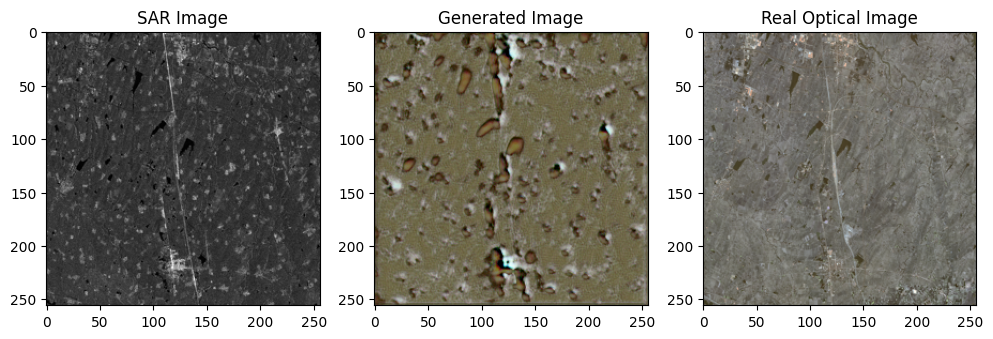

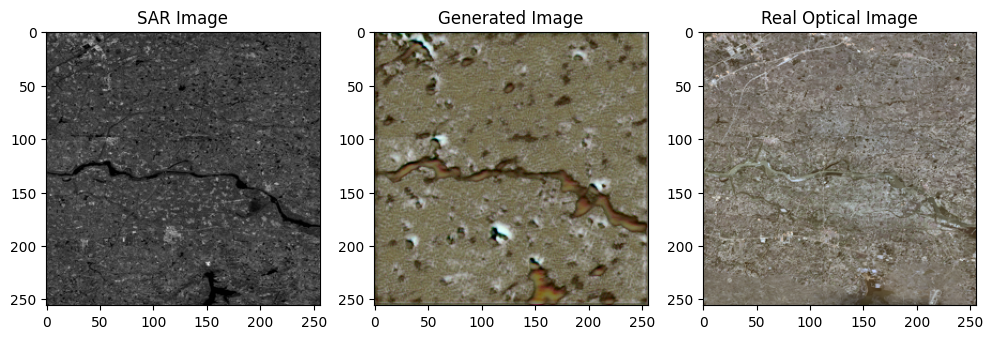

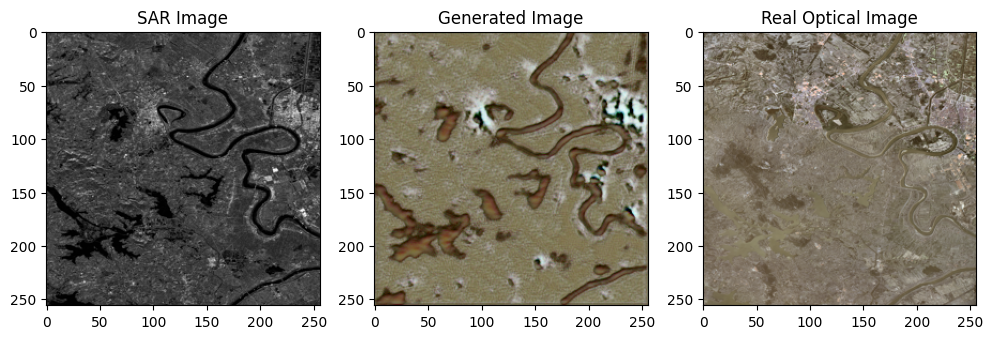

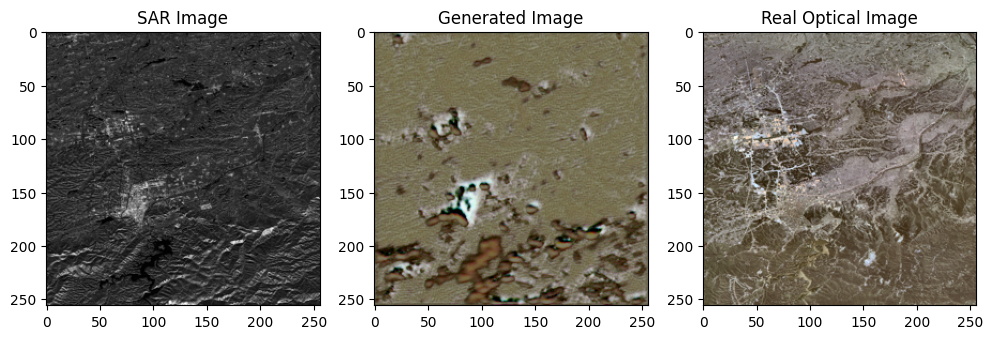

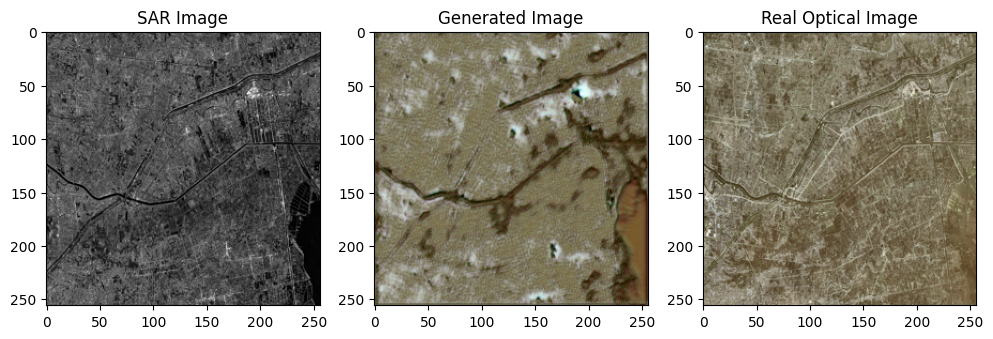

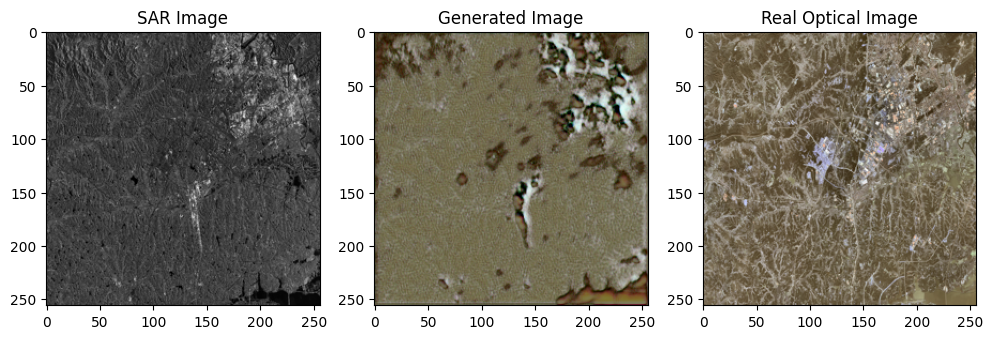

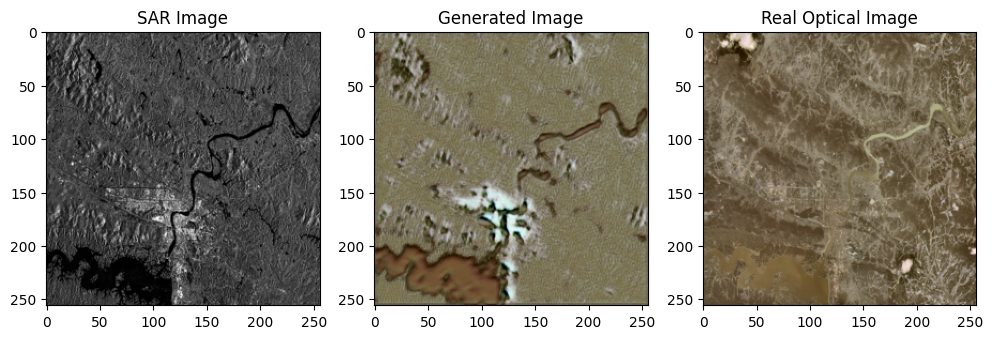

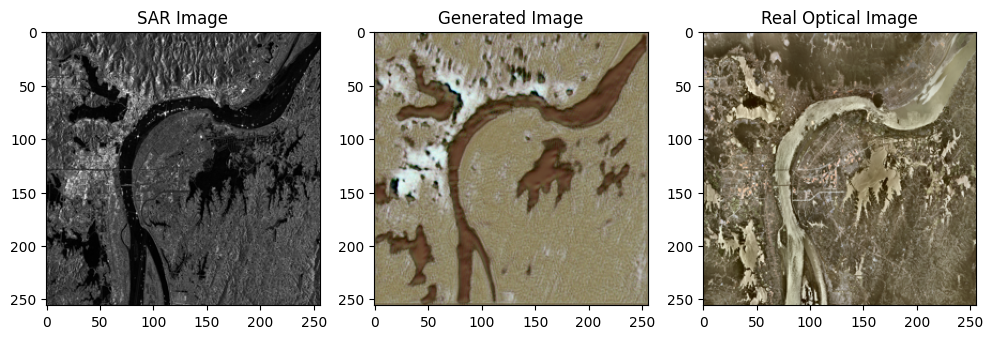

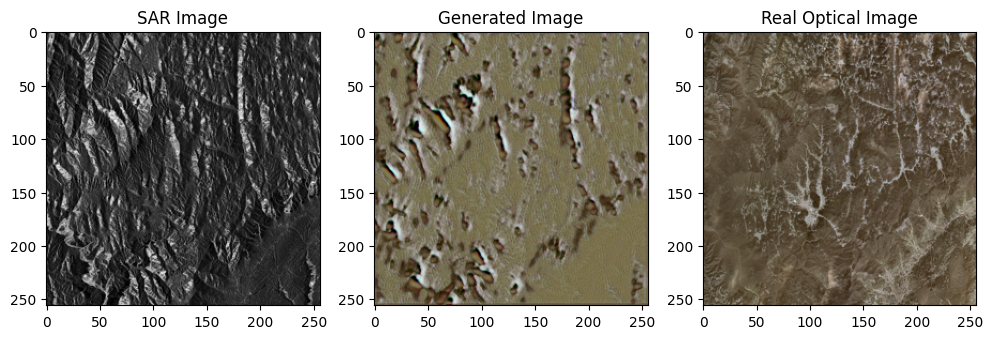

In [7]:
# Load the best checkpoint for testing
def load_best_checkpoint_for_testing(generator):
    gen_checkpoint_path, _ = get_latest_checkpoint(checkpoint_dir, model_type='generator')
    if gen_checkpoint_path:
        print(f"Loading Generator from: {gen_checkpoint_path}")
        gen_checkpoint = torch.load(gen_checkpoint_path)
        generator.load_state_dict(gen_checkpoint['model_state_dict'])
        print("Generator loaded for testing")

# Load the best generator checkpoint
load_best_checkpoint_for_testing(generator)

# Set the generator to evaluation mode
generator.eval()

# Function to perform testing
def test_model(generator, test_loader):
    with torch.no_grad():
        for i, data in enumerate(test_loader):
            sar_images, real_images = data
            sar_images, real_images = sar_images.to(device), real_images.to(device)

            # Generate fake images from SAR inputs
            fake_images = generator(sar_images)

            # Resize generated images to match real images dimensions
            fake_images = F.interpolate(fake_images, size=real_images.shape[2:], mode='bilinear', align_corners=False)

            # Display results
            display_images(sar_images, real_images, fake_images)

            # Break after the first batch for quick testing (remove this line to test the entire dataset)
            # if i == 0:
            #     break

# Run the test function
test_model(generator, test_loader)
